# Long Baseline Study of Mira Variable Stars: Part One
## Data Mining

### Accessing and Loading Light Curve Data from AAVSO, Gaia DR3, and ASAS-SN

#### Step One
To access data from AAVSO, submit a request at https://www.aavso.org/data-download. Use "all" for the start and end dates, and select tab-delimited. It will generate a .txt file for you to download.
To access Gaia data, use the Single Object tab at https://gea.esac.esa.int/archive/. Download the Epoch Photometry data with Individual structure and as either .csv or .fits.
To access ASAS-SN data, export it as a .csv from their photometry database at https://asas-sn.osu.edu/photometry. Note you may also use their light curve data for well known variables as I will be doing in this example for R Aql.

#### Step Two
Now, we need to load the basic lightcurve data. To do this, we select the time and magnitude columns from each .fits or .csv file.

In [4]:
#Start with all of our imports:
import pandas as pd
import numpy as np
from astropy.table import Table, vstack
from astropy.io import fits
from astropy.time import Time
import matplotlib.pyplot as plt
%matplotlib widget
import math
import sys
import os
from datetime import datetime
import libwwz as wwz
from libwwz.wwz import wwt
import libwwz.plot_methods as wwz_plot
from pyleoclim import utils
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter
import lightkurve as lk
import glob

['JD', 'Magnitude', 'Uncertainty', 'HQuncertainty', 'Band', 'Observer Code', 'Comment Code(s)', 'Comp Star 1', 'Comp Star 2', 'Charts', 'Comments', 'Transfomed', 'Airmass', 'Validation Flag', 'Cmag', 'Kmag', 'HJD', 'Star Name', 'Observer Affiliation', 'Measurement Method', 'Grouping Method', 'ADS Reference', 'Digitizer', 'Credit']
['JD', 'Flux', 'Flux Error', 'Mag', 'Mag Error', 'Limit', 'FWHM', 'Filter', 'Quality', 'Camera']
0       b'V'
1       b'V'
2       b'V'
3       b'V'
4       b'V'
        ... 
2011    b'g'
2012    b'g'
2013    b'g'
2014    b'g'
2015    b'g'
Name: Filter, Length: 2016, dtype: object
['transit_id', 'g_transit_time', 'g_transit_flux', 'g_transit_flux_error', 'g_transit_flux_over_error', 'g_transit_mag', 'bp_obs_time', 'bp_flux', 'bp_flux_error', 'bp_flux_over_error', 'bp_mag', 'rp_obs_time', 'rp_flux', 'rp_flux_error', 'rp_flux_over_error', 'rp_mag', 'variability_flag_g_reject', 'variability_flag_bp_reject', 'variability_flag_rp_reject', 'g_other_flags', 'bp_othe

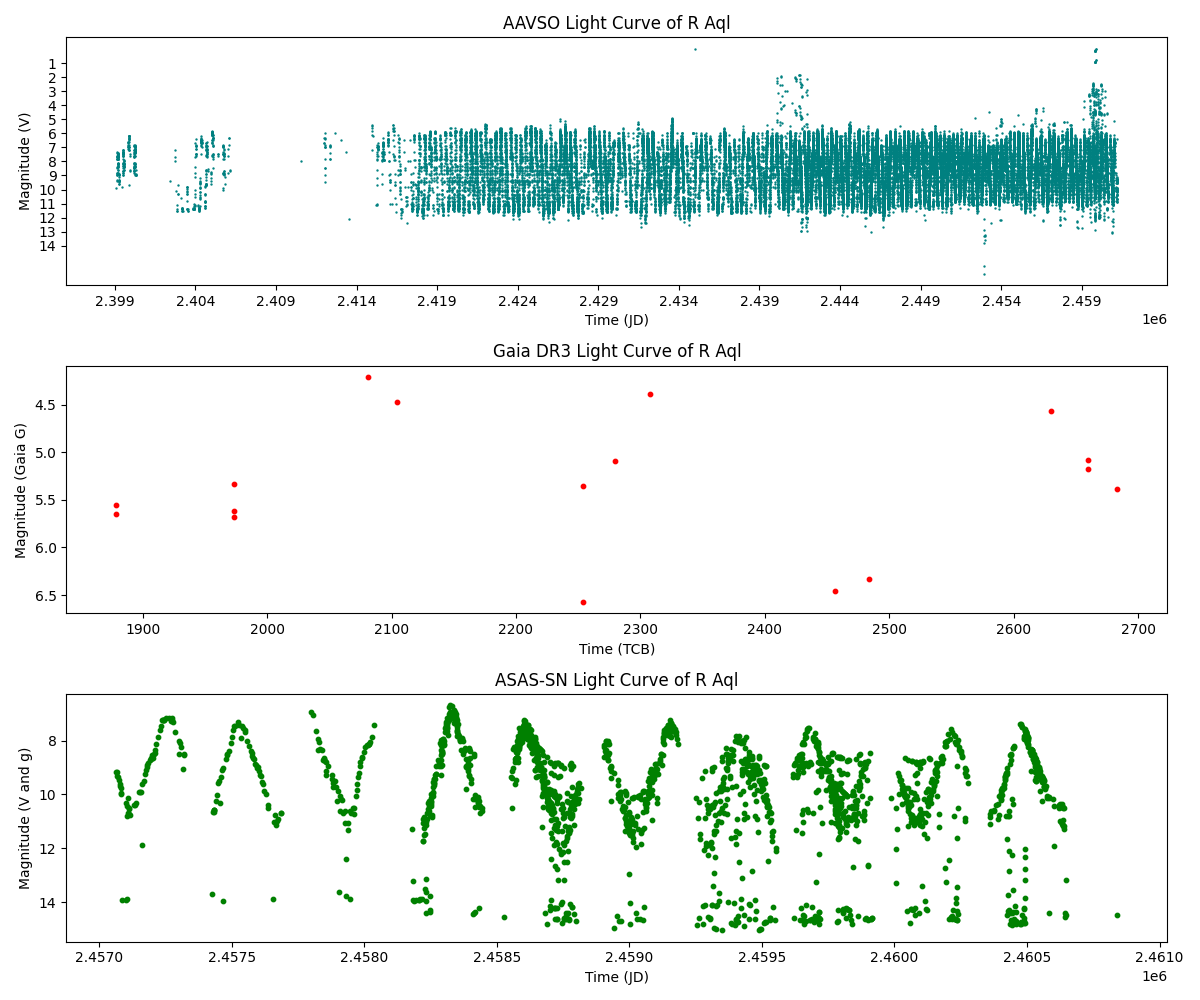

In [7]:
#Since AAVSO returns a .txt file, we can either use a pandas dataframe or convert it to .fits. I will show both options.
df_aavso = pd.read_csv('/raid6/users/rantoine/R_Aql/Light_Curves/R_Aql_aavsodata_tab.txt', sep='\t', dtype=object, low_memory=False)
print(df_aavso.columns.tolist())
for col in df_aavso.columns:
    df_aavso[col] = df_aavso[col].str.strip().str.encode('ascii', errors='replace').str.decode('ascii')
astro_table = Table.from_pandas(df_aavso)
astro_table.write('R_Aql_aavso.fits', format='fits', overwrite=True)

# From here, you could work with the .fits file or continue reading with pandas as seen below.
df_aavso["JD"] = pd.to_numeric(df_aavso["JD"], errors="coerce")
df_aavso["Magnitude"] = pd.to_numeric(df_aavso["Magnitude"], errors="coerce")
df_aavso = df_aavso.dropna(subset=["JD", "Magnitude"])

#I will also convert the .csv from ASAS-SN to a fits.
df_asassn = pd.read_csv('/raid6/users/rantoine/R_Aql/Light_Curves/197569517963-light-curves.csv', sep=',', dtype=object, low_memory=False, skiprows=6)
print(df_asassn.columns.tolist())
for col in df_asassn.select_dtypes(include=['object']).columns:
    df_asassn[col] = df_asassn[col].astype(str).str.encode('utf-8', errors='replace')

astro_table = Table.from_pandas(df_asassn)
astro_table.write('R_Aql_asas-sn.fits', format='fits', overwrite=True)
print(df_asassn['Filter']) #to check

df_asassn["JD"] = pd.to_numeric(df_asassn["JD"], errors="coerce")
df_asassn["Mag"] = pd.to_numeric(df_asassn["Mag"], errors="coerce")
df_asassn = df_asassn.dropna(subset=["JD", "Mag"])


#Now let's read all of our fits files and create subplots.
#aavso = Table.read('R_Aql_aavso.fits')
#aavso_time = aavso['JD']
#aavso_mag = aavso['Magnitude']
gaia = Table.read('/raid6/users/rantoine/R_Aql/Light_Curves/EPOCH_PHOTOMETRY-Gaia DR3 4307450193249412352.fits')
gaia_time = gaia['g_transit_time']
gaia_mag = gaia['g_transit_mag']
#asassn = Table.read('R_Aql_asas-sn.fits')
#asassn_time = asassn['hjd']
#asassn_mag = asassn['mag']
#Note: To check yout column names, you can print(data.colnames) where data is your read .fits file.
print(gaia.colnames)
#Okay now lets set up our subplots.
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 10))

axes[0].scatter(df_aavso['JD'], df_aavso['Magnitude'], color='teal', s=0.5) #I switched back to using the pandas df because the fits file was being wonky
axes[0].set_xlabel('Time (JD)')
axes[0].set_ylabel('Magnitude (V)')
axes[0].invert_yaxis()
axes[0].set_title('AAVSO Light Curve of R Aql')
axes[0].set_xticks(np.arange(2399000.0, 2460000, 5000))
axes[0].set_yticks(np.arange(1, 15, 1))
axes[1].scatter(gaia_time, gaia_mag, color='red', s=10)
axes[1].set_xlabel('Time (TCB)')
axes[1].set_ylabel('Magnitude (Gaia G)')
axes[1].set_title('Gaia DR3 Light Curve of R Aql')
axes[1].invert_yaxis()
axes[2].scatter(df_asassn['JD'], df_asassn['Mag'], color='green', s=10) #Same use of df here
axes[2].set_xlabel('Time (JD)')
axes[2].set_ylabel('Magnitude (V and g)')
axes[2].invert_yaxis()
axes[2].set_title('ASAS-SN Light Curve of R Aql')

plt.tight_layout()
plt.show()

#### Step Three
So by invesitigating the above plots, you might notice that the parameters are different. We have various magnitudes and timescales, so we need to do some conversions to properly compare and combine everything.

In [8]:
#Let's start by putting everything in the same filter. To do so, we need to convert Gaia G band to Johnson V. This conversion comes from the G-V relation in table 5.7 of
#https://gea.esac.esa.int/archive/documentation/GEDR3/Data_processing/chap_cu5pho/cu5pho_sec_photSystem/cu5pho_ssec_photRelations.html.
bp_rp = gaia['bp_mag'] - gaia['rp_mag']
G = gaia['g_transit_mag']
V = -(-0.02704 + 0.01424*(bp_rp) - 0.215*(bp_rp**2) + 0.01426*(bp_rp**3) - G)
gaia['V_mag'] = V
#print(gaia['V_mag']) to check

#Now we need everything in JD, not TCB or HJD
#We will use astopy.time and start with Gaia
tcb_jd_corrected = gaia['g_transit_time'] + 2455197.5 #offset provided by gaia
gaia_tcb = Time(tcb_jd_corrected, scale='tcb', format = 'jd')
gaia_jd = gaia_tcb.jd
gaia['JD'] = gaia_jd
gaia.write("EPOCH_PHOTOMETRY-Gaia DR3 4307450193249412352.fits", overwrite=True)
#print(gaia_jd) #to check

#Let's move on to ASAS-SN. We have a different adjustment to make here. There are two filters used and included in our .csv file, so we need to either:
#a) mask out the data with g magnitude measurements
# or b) convert the g magnitude to V, which is more difficult so I'm not choosing this option for now.
V_mask = df_asassn['Filter'] == b'V'
df_asassn_V = df_asassn[V_mask]
#print(df_asassn_V['Filter']) #to check
#Note that this filter drop our data from 2016 observations to 233. This might make it worth it to revisit option b) above and convert g to V in the future.

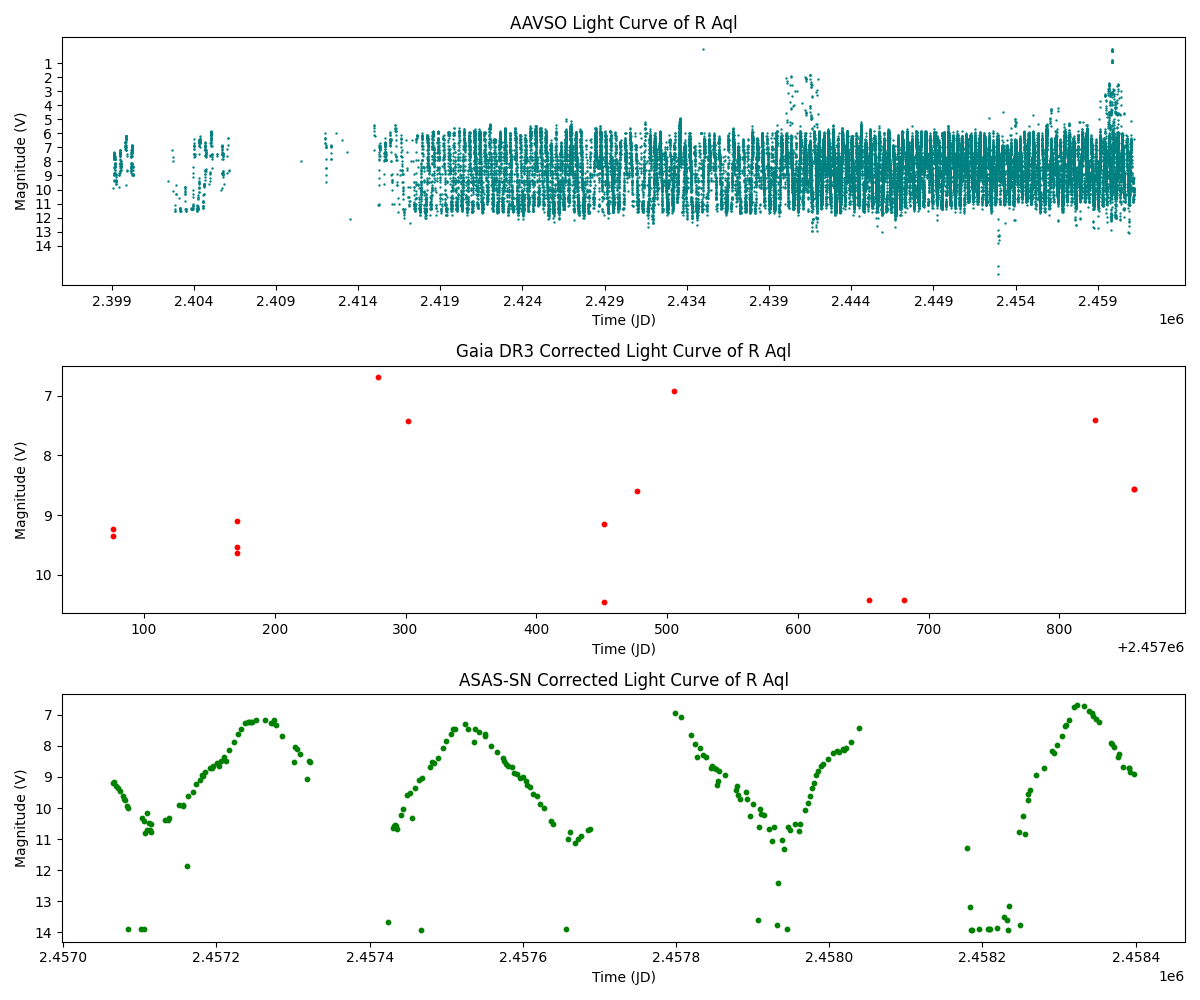

In [9]:
#Now, let's replot the same plot initially, to see what changes me made.
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 10))

axes[0].scatter(df_aavso['JD'], df_aavso['Magnitude'], color='teal', s=0.5) #I switched back to using the pandas df because the fits file was being wonky
axes[0].set_xlabel('Time (JD)')
axes[0].set_ylabel('Magnitude (V)')
axes[0].invert_yaxis()
axes[0].set_title('AAVSO Light Curve of R Aql')
axes[0].set_xticks(np.arange(2399000.0, 2460000, 5000))
axes[0].set_yticks(np.arange(1, 15, 1))
axes[1].scatter(gaia['JD'], gaia['V_mag'], color='red', s=10)
axes[1].set_xlabel('Time (JD)')
axes[1].set_ylabel('Magnitude (V)')
axes[1].set_title('Gaia DR3 Corrected Light Curve of R Aql')
axes[1].invert_yaxis()
axes[2].scatter(df_asassn_V['JD'], df_asassn_V['Mag'], color='green', s=10) #Same use of df here
axes[2].set_xlabel('Time (JD)')
axes[2].set_ylabel('Magnitude (V)')
axes[2].invert_yaxis()
axes[2].set_title('ASAS-SN Corrected Light Curve of R Aql')

plt.tight_layout()
plt.show()

#### Step Four
Now that we have everything in V magnitude and JD, we can combine the plot all of the data on the same plot.

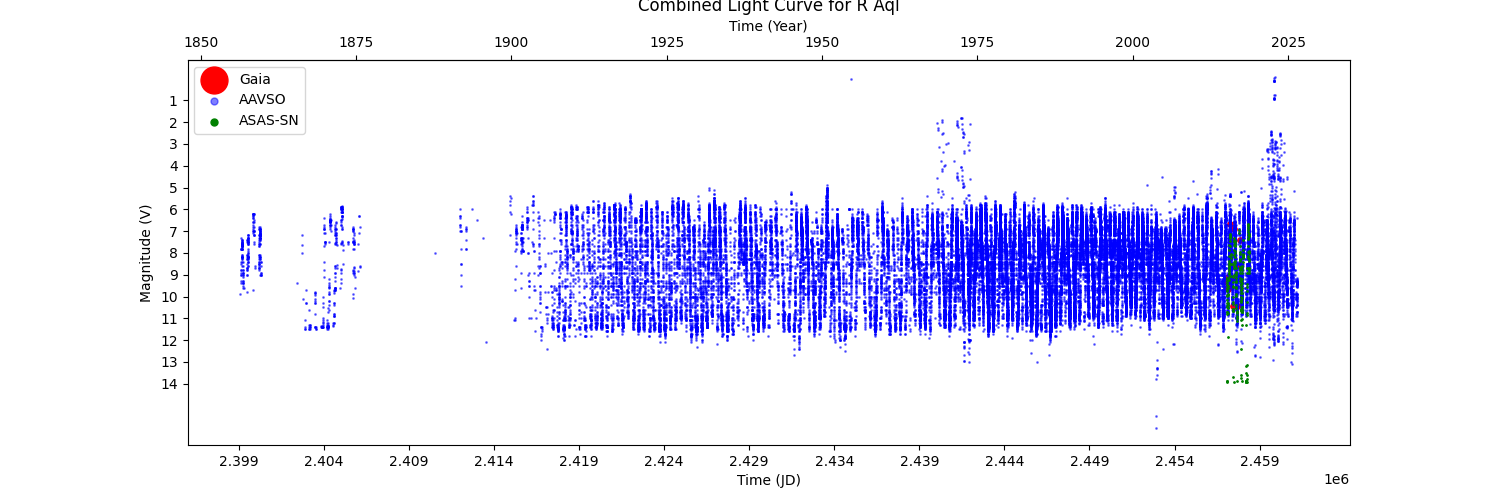

In [10]:
#First, we call the columns we want to plot.
gaia_time = gaia['JD']
gaia_mag = gaia['V_mag']

aavso_time = df_aavso['JD']
aavso_mag = df_aavso['Magnitude']

asassn_time = df_asassn_V['JD']
asassn_mag = df_asassn_V['Mag']

#Now, we set up the subplots.
fig, ax = plt.subplots(figsize = (15,5))
ax.scatter(gaia_time, gaia_mag, color='r', s=15, label='Gaia', alpha=1)
ax.scatter(aavso_time, aavso_mag, color='b', s=1, label='AAVSO', alpha=0.5)
ax.scatter(asassn_time, asassn_mag, color='g', s=1, label='ASAS-SN', alpha=1)

ax.set_xticks(np.arange(2399000.0, 2460000, 5000))
ax.set_yticks(np.arange(1, 15, 1))
ax.invert_yaxis()

ax.set_xlabel('Time (JD)') #Notice how it's all the same now!
ax.set_ylabel('Magnitude (V)')
ax.set_title('Combined Light Curve for R Aql')
ax.legend(markerscale=5)

#This shows the year at the top, since JD is not as recognizable.
def jd_to_year(jd):
    jd = np.atleast_1d(jd).astype(float)
    return Time(jd, format='jd').jyear

def year_to_jd(year):
    year = np.atleast_1d(year).astype(float)
    return Time(year, format='jyear').jd

secax = ax.secondary_xaxis('top', functions=(jd_to_year, year_to_jd))
secax.set_xlabel('Time (Year)')

plt.show()

Side Note: There still seem to be outliers in both the AAVSO and ASAS-SN data. Seeing as both source their observations from various places, I would like to investigate if there is certain data I should drop.

In [12]:
#Next, I want to write each database their own light curve data with the same column names.
aavso_lc = df_aavso[['JD', 'Magnitude']]
aavso_table = Table.from_pandas(aavso_lc)
aavso_table.write('aavso_lc_R_Aql.fits', overwrite=True)
gaia_lc = gaia['JD', 'V_mag']
gaia_lc.rename_column('V_mag', 'Magnitude')
gaia_lc.write('gaia_lc_R_Aql.fits', overwrite=True)
asassn_lc = df_asassn[['JD', 'Mag']]
asassn_table = Table.from_pandas(asassn_lc)
asassn_table.rename_column('Mag', 'Magnitude')
asassn_table.write('asassn_lc_R_Aql.fits', overwrite=True)

#Now let's combine them.
AAVSO = Table.read('aavso_lc_R_Aql.fits')
Gaia = Table.read('gaia_lc_R_Aql.fits')
ASASSN = Table.read('asassn_lc_R_Aql.fits')
#AAVSO and ASASSN data does not match up with gaia becuase they are strings rather than float.
def jd_bytes_to_float(tbl):
    tbl = tbl.copy()
    if tbl['JD'].dtype.kind in ('S', 'b'):  # byte string
        tbl['JD'] = tbl['JD'].astype(str).astype(np.float64)
    return tbl
def mag_bytes_to_float(tbl):
    tbl = tbl.copy()
    if tbl['Magnitude'].dtype.kind in ('S', 'b'):
        mag_str = tbl['Magnitude'].astype(str)
        tbl['is_upperlim'] = np.array([s.startswith('<') for s in mag_str], dtype=bool)
        tbl['is_lowerlim'] = np.array([s.startswith('>') for s in mag_str], dtype=bool)
        mag_clean = np.array([s.strip().lstrip('<>') for s in mag_str])
        tbl['Magnitude'] = mag_clean.astype(np.float64)
    return tbl

#Applying the function to convert btyes to float.
AAVSO  = jd_bytes_to_float(AAVSO)
ASASSN = jd_bytes_to_float(ASASSN)
AAVSO  = mag_bytes_to_float(AAVSO)
ASASSN = mag_bytes_to_float(ASASSN)

#Now we can combine them with vstack!
combined_lc = vstack([AAVSO, Gaia, ASASSN])
combined_lc.write('combined_lc_R_Aql.fits', format='fits', overwrite=True)

#### Step Five
Now that we have a large lightcurve spanning fromt he late 1850s to now, let's calculate its period using a tool from pyleoclim called Weight Wavelet Z-transform. WWZ was initially created by Foster in a 1961 paper to calculate the period of time series data with frequent gaps.

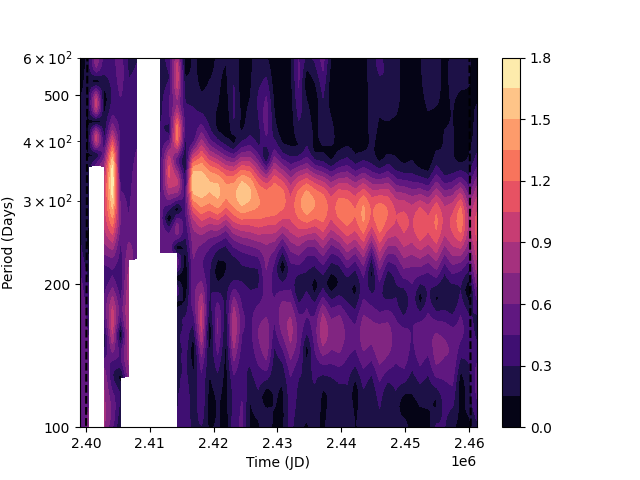

In [13]:
#This section is taken from the pyleoclim example with our data inputed.
combined_data = Table.read('combined_lc_R_Aql.fits')
time = combined_data['JD']
magnitude = combined_data['Magnitude']
signal = -(magnitude - np.mean(magnitude))

# Wavelet Analysis
res = utils.wwz(signal, time)

# Visualization
fig, ax = plt.subplots()

contourf_args = {'cmap': 'magma', 'origin': 'lower', 'levels': 11}

cbar_args = {'drawedges': False, 'orientation': 'vertical', 'fraction': 0.15, 'pad': 0.05}

cont = ax.contourf(res.time, 1/res.freq, res.amplitude.T, **contourf_args)

ax.plot(res.time, res.coi, 'k--')  # plot the cone of influence

ax.set_yscale('log')

ax.set_yticks([2, 5, 10, 20, 50, 100, 200, 500, 1000])

ax.set_ylim([100, 600])

ax.yaxis.set_major_formatter(ScalarFormatter())

ax.yaxis.set_major_formatter(FormatStrFormatter('%g'))

ax.set_xlabel('Time (JD)')

ax.set_ylabel('Period (Days)')

cb = plt.colorbar(cont, **cbar_args)

plt.show()

Great! This WWZ plot matches up with the period decline of R Aql published in literature.

Side note: I still want to complete WWZ on pieces of the light curve (not just the whole thing) and figure out how to extract the actual value of the period -- either from the graph itself or from printing something.

#### Step Six
Now that we have done the majority* of the data mining, let's compare what data the plates will provide for us!
*Majority meaning we can always add more databases, drop extraneous data, and complete different variations of period analysis.

Text(0.5, 1.0, 'Event Plot for Plate Data')

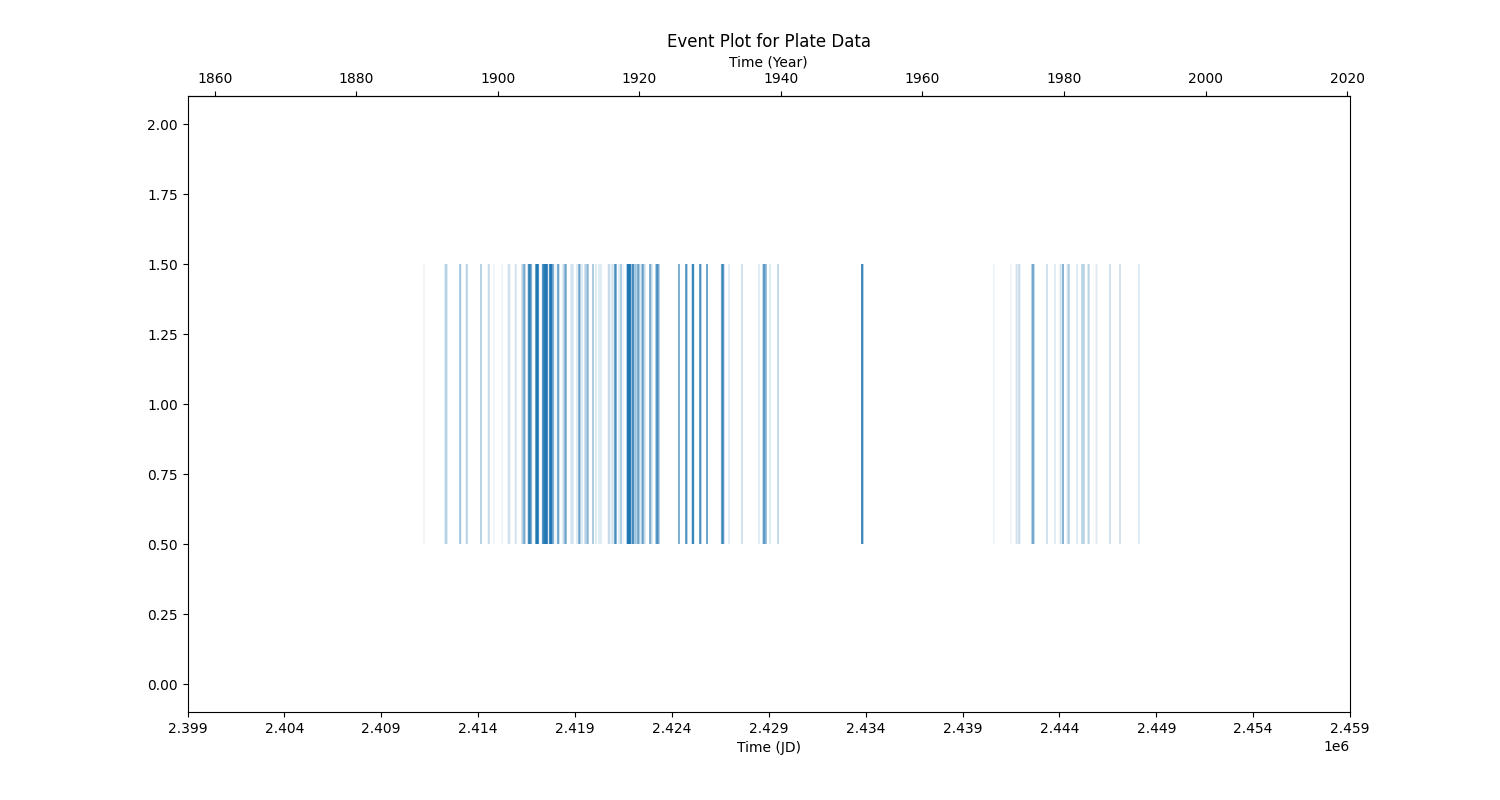

In [14]:
#Let's start with an event plot for the glass plates. Before then, however, I had to edit a lot of the files to match the same Date format.
target_column = 'Date'
all_tables = []
for filepath in glob.glob('/raid6/users/rantoine/R_Aql/Data/*.csv'):
    file = Table.read(filepath)
 
    if target_column in file.colnames:
        sub_table = file[[target_column]]
        short_name = filepath.split('/')[-1]
        sub_table['source_file'] = short_name
        all_tables.append(sub_table)

plate_data = vstack(all_tables)

time = Time(plate_data['Date'], scale='utc')
plate_data['JD'] = time.jd

fig, ax1 = plt.subplots(figsize = (15,8))
ax1.eventplot(plate_data['JD'], linewidth=0.1)

jd_ticks = np.arange(2399000.0, 2460000, 5000)
ax1.set_xticks(jd_ticks)
ax1.set_xlim(jd_ticks[0], jd_ticks[-1])
ax1.set_xlabel('Time (JD)')

def jd_to_year(jd):
    jd = np.atleast_1d(jd).astype(float)
    return Time(jd, format='jd').jyear

def year_to_jd(year):
    year = np.atleast_1d(year).astype(float)
    return Time(year, format='jyear').jd

secax = ax1.secondary_xaxis('top', functions=(jd_to_year, year_to_jd))
secax.set_xlabel('Time (Year)')

plt.title('Event Plot for Plate Data')

Text(0.5, 1.0, 'Event Plot from Data Mining')

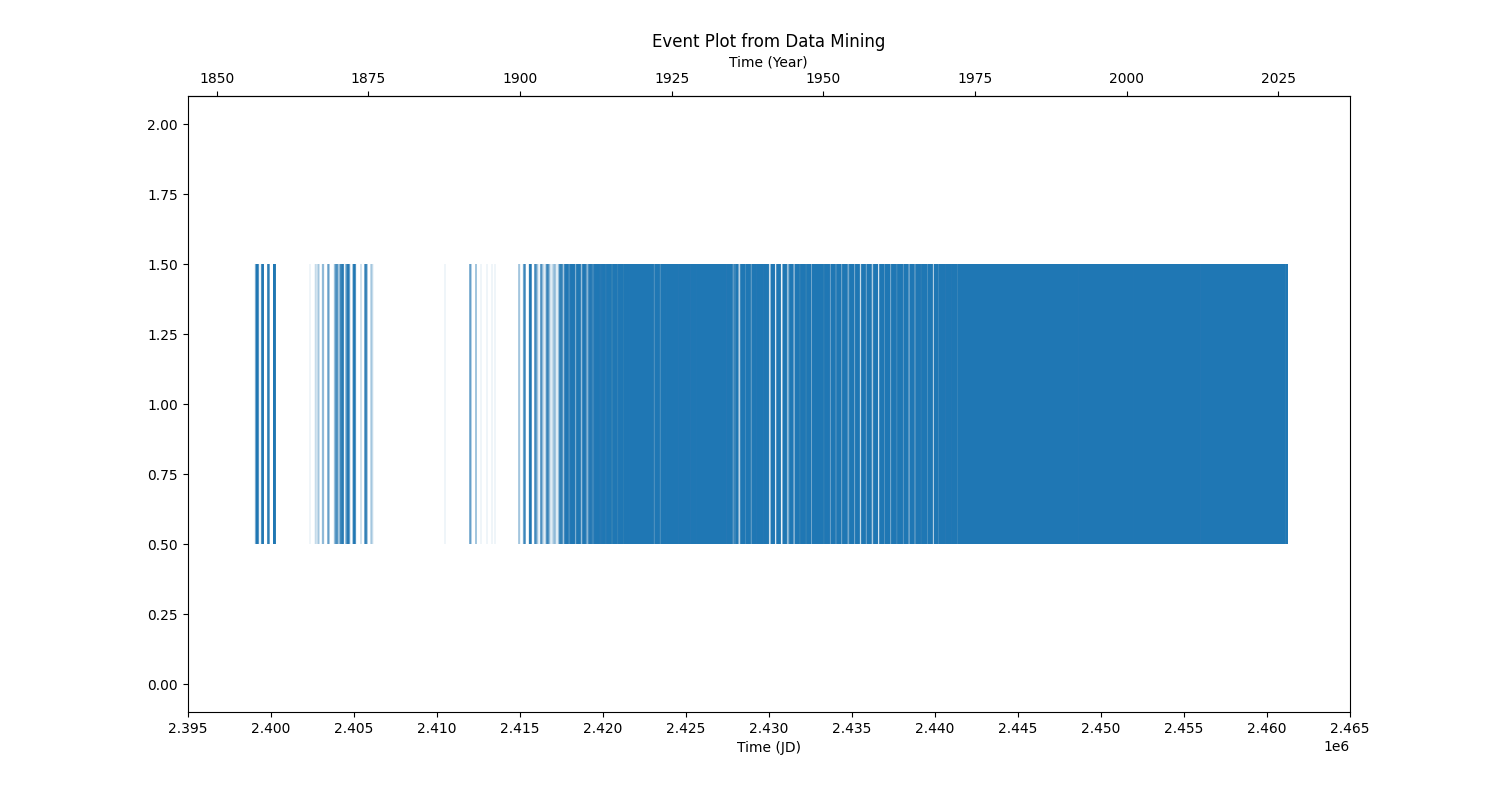

In [15]:
#Now we can check it for our data mining results.

fig, ax1 = plt.subplots(figsize = (15,8))
ax1.eventplot(combined_data['JD'], linewidth=0.1)

jd_ticks = np.arange(2395000.0, 2470000, 5000)
ax1.set_xticks(jd_ticks)
ax1.set_xlim(jd_ticks[0], jd_ticks[-1])
ax1.set_xlabel('Time (JD)')

def jd_to_year(jd):
    jd = np.atleast_1d(jd).astype(float)
    return Time(jd, format='jd').jyear

def year_to_jd(year):
    year = np.atleast_1d(year).astype(float)
    return Time(year, format='jyear').jd

secax = ax1.secondary_xaxis('top', functions=(jd_to_year, year_to_jd))
secax.set_xlabel('Time (Year)')

plt.title('Event Plot from Data Mining')

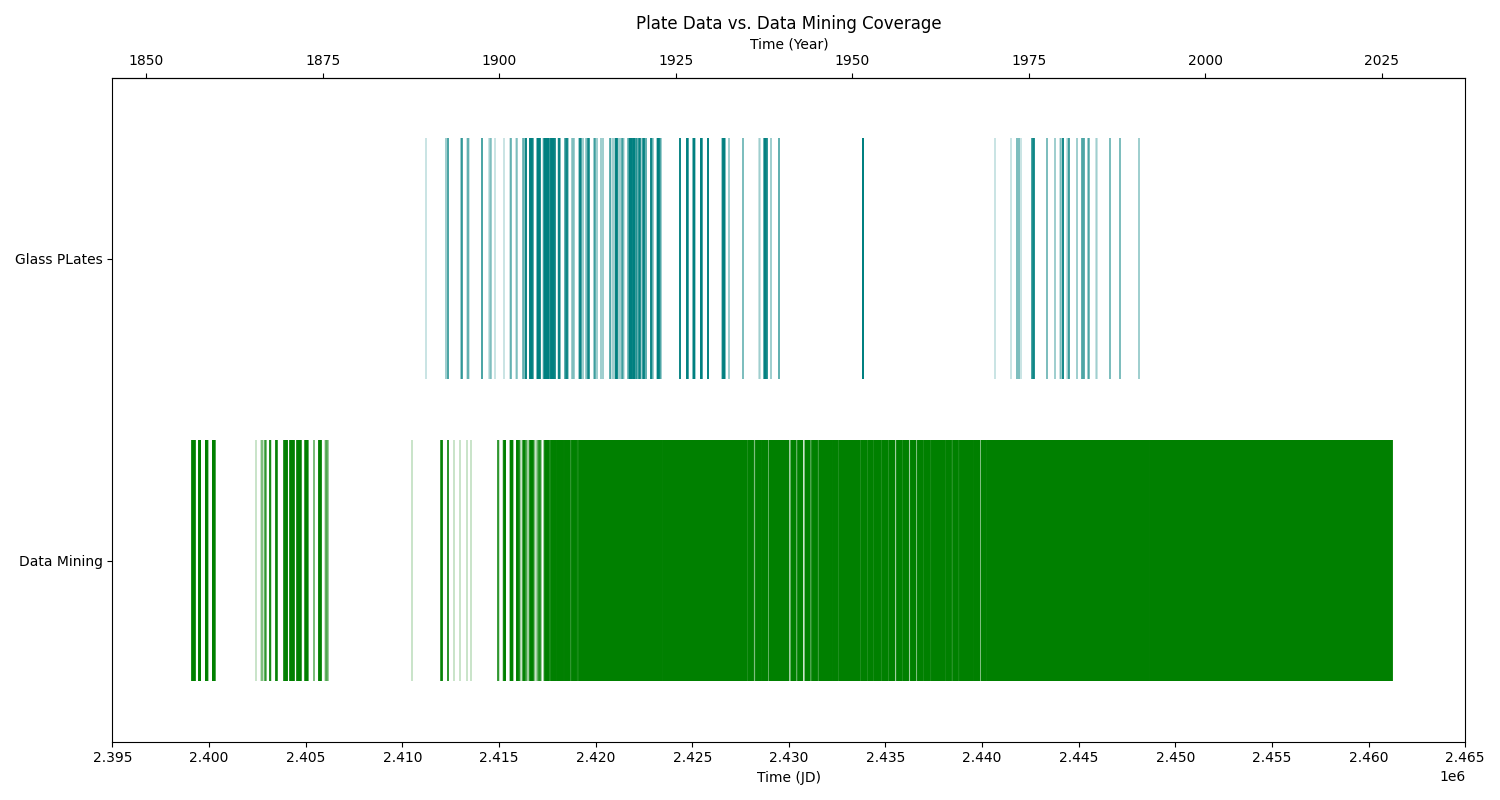

In [16]:
#Now let's stack them to see if the plates fill in any gaps.
fig, ax1 = plt.subplots(figsize=(15, 8))


ax1.eventplot(
    [plate_data['JD'], combined_data['JD']],
    lineoffsets=[1, 0],      
    linelengths=[0.8, 0.8],
    colors=['teal', 'green'],
    linewidths=0.3
)

ax1.set_yticks([0, 1])
ax1.set_yticklabels(['Data Mining', 'Glass PLates'])
ax1.set_ylim(-0.6, 1.6)

jd_min = min(combined_data['JD'].min(), plate_data['JD'].min())
jd_max = max(combined_data['JD'].max(), plate_data['JD'].max())
jd_ticks = np.arange(np.floor(jd_min/5000)*5000, np.ceil(jd_max/5000)*5000 + 1, 5000)

ax1.set_xticks(jd_ticks)
ax1.set_xlim(jd_ticks[0], jd_ticks[-1])
ax1.set_xlabel('Time (JD)')

def jd_to_year(jd):
    jd = np.atleast_1d(jd).astype(float)
    return Time(jd, format='jd').jyear

def year_to_jd(year):
    year = np.atleast_1d(year).astype(float)
    return Time(year, format='jyear').jd

secax = ax1.secondary_xaxis('top', functions=(jd_to_year, year_to_jd))
secax.set_xlabel('Time (Year)')

ax1.set_title('Plate Data vs. Data Mining Coverage')
plt.tight_layout()
plt.show()

Now at this point, it may seem like the glass plates don't add much, but R Aql is just the validation star! Other stars not so heavily studied (such as ST Sct that AAVSO has NO data on) show up extensively in glass plates!

***This is the end of Part One! Move on to Part Two to start analyzing glass plates!***